# 2. Combined environmental data analysis

This notebook combines the useful analysis from the earlier separate data notebooks into one cleaned overview.

The goal is not to rebuild every file by hand here. The real pipeline is kept in scripts. This notebook is for checking the input datasets, comparing their structure, and explaining why the final unified dataset looks the way it does.


## Notebook scope

The older notebooks looked at the datasets separately:

- `1c_mock_data.ipynb` compared the first mock/environment datasets and KETI data.
- `3_mock_data.ipynb` analysed the HomeCoach 2023-2026 files.
- `4_mock_data.ipynb` analysed the room measurement and comfort perception files.
- `5_unified_environment_dataset.ipynb` analysed the final unified dataset.

This notebook brings those parts together and removes duplicated or outdated cells.
You can find these notebooks in `MAL/notebooks/archive`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

DATA_DIR = Path("../../data")
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

DATA_DIR

WindowsPath('../../data')

## Data source overview

The final pipeline uses a mix of raw data, interim KETI data, and processed helper files. Dataset 7 and 8 used to be analysed separately, so they are included here explicitly.


In [2]:
source_paths = {
    "Data 1 - room conditions": RAW_DIR / "DATA_1" / "room_conditions.csv",
    "Data 2 - agile teaching": RAW_DIR / "DATA_2" / "agile_teaching_dataset.csv",
    "Data 3 - environmental design": RAW_DIR / "DATA_3" / "environmental_design_dataset.csv",
    "Data 4 - green building": RAW_DIR / "DATA_4" / "green_building_dataset.csv",
    "Data 5 - mental health IoT": RAW_DIR / "DATA_5" / "university_mental_health_iot_dataset.csv",
    "Data 6 - KETI resampled": INTERIM_DIR / "keti_1min_resampled.csv",
    "Data 7 - HomeCoach 2023": RAW_DIR / "DATA_7" / "HomeCoach_5min_2023.csv",
    "Data 7 - HomeCoach 2024": RAW_DIR / "DATA_7" / "HomeCoach_5min_2024.csv",
    "Data 7 - HomeCoach 2025": RAW_DIR / "DATA_7" / "HomeCoach_5min_2025.csv",
    "Data 7 - HomeCoach 2026": RAW_DIR / "DATA_7" / "HomeCoach_5min_2026.csv",
    "Data 8 - room measurements": RAW_DIR / "DATA_8" / "smart-campus-comfort-data" / "1_room_measurements.csv",
    "Data 8 - comfort perception": RAW_DIR / "DATA_8" / "smart-campus-comfort-data" / "4_comfort_perception.csv",
}

source_overview = []

for name, path in source_paths.items():
    if not path.exists():
        source_overview.append({"dataset": name, "exists": False})
        continue

    preview = pd.read_csv(path, nrows=5, low_memory=False)
    rows = sum(1 for _ in open(path, encoding="utf-8", errors="ignore")) - 1

    source_overview.append({
        "dataset": name,
        "exists": True,
        "rows": rows,
        "columns": len(preview.columns),
        "path": str(path),
    })

source_overview = pd.DataFrame(source_overview)
source_overview

,dataset,exists,rows,columns,path
0,Data 1 - room conditions,True,2665,8,..\..\data\raw\DATA_1\room_conditions.csv
1,Data 2 - agile teaching,True,3500,17,..\..\data\raw\DATA_2\agile_teaching_dataset.csv
2,Data 3 - environmental design,True,6480,16,..\..\data\raw\DATA_3\environmental_design_dat...
3,Data 4 - green building,True,2400,19,..\..\data\raw\DATA_4\green_building_dataset.csv
4,Data 5 - mental health IoT,True,1000,12,..\..\data\raw\DATA_5\university_mental_health...
5,Data 6 - KETI resampled,True,604891,12,..\..\data\interim\keti_1min_resampled.csv
6,Data 7 - HomeCoach 2023,True,77045,6,..\..\data\raw\DATA_7\HomeCoach_5min_2023.csv
7,Data 7 - HomeCoach 2024,True,100325,6,..\..\data\raw\DATA_7\HomeCoach_5min_2024.csv
8,Data 7 - HomeCoach 2025,True,100190,6,..\..\data\raw\DATA_7\HomeCoach_5min_2025.csv
9,Data 7 - HomeCoach 2026,True,34132,6,..\..\data\raw\DATA_7\HomeCoach_5min_2026.csv


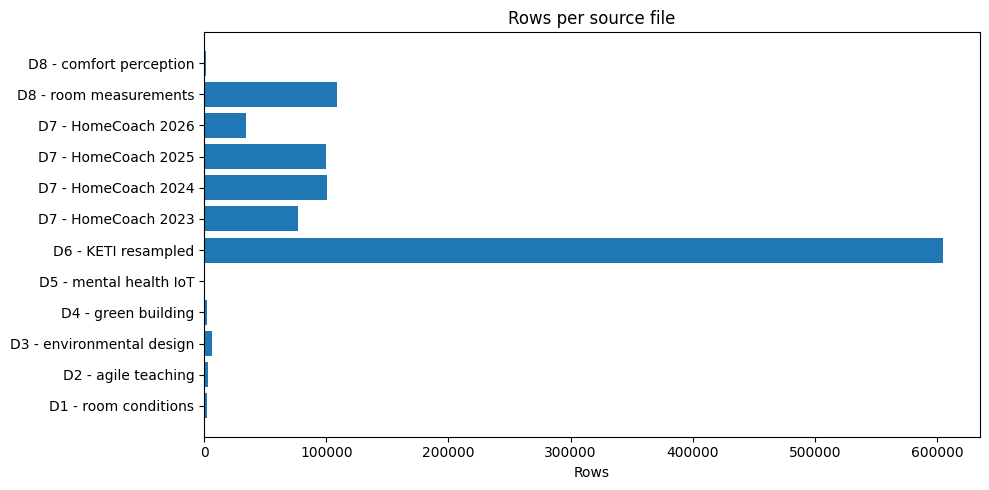

In [3]:
plt.figure(figsize=(10, 5))
plot_df = source_overview[source_overview["exists"]].copy()
plot_df["short_name"] = plot_df["dataset"].str.replace("Data ", "D", regex=False)

plt.barh(plot_df["short_name"], plot_df["rows"])
plt.xlabel("Rows")
plt.title("Rows per source file")
plt.tight_layout()
plt.show()

## Common sensor column mapping

The source datasets use different column names for the same environmental concepts. Before comparing them, we map similar columns into a common set: temperature, humidity, light, noise, CO2, and target-like score.


In [4]:
def normalise_name(name):
    return "".join(ch for ch in str(name).lower() if ch.isalnum())


column_candidates = {
    "timestamp": ["timestamp", "date", "datetime", "time"],
    "temperature": ["temperature", "temp", "currenttemperature", "temperaturecelsius", "indoortemperature", "skintemp"],
    "humidity": ["humidity", "relativehumidity", "humiditypercent", "indoorhumidity"],
    "light": ["light", "ambientlight", "illumination", "illuminance", "lightinglux", "indoorlighting", "lux"],
    "noise": ["noise", "ambientnoise", "sound", "soundlevel", "noiselevel", "noiseleveldb", "indoornoise"],
    "co2": ["co2", "co2level", "carbonDioxide", "co2concentration"],
    "target_like": ["focusscore", "target", "rating", "comfortscore", "comfortvalue", "predictedcomfortindex"],
}


def find_column(columns, candidates):
    normalised = {normalise_name(column): column for column in columns}
    for candidate in candidates:
        match = normalised.get(normalise_name(candidate))
        if match is not None:
            return match
    return None


def source_sensor_view(path, dataset_name):
    df = pd.read_csv(path, low_memory=False)
    out = pd.DataFrame(index=df.index)
    out["dataset"] = dataset_name

    for standard_name, candidates in column_candidates.items():
        column = find_column(df.columns, candidates)
        if column is None:
            out[standard_name] = pd.NA
        else:
            out[standard_name] = df[column]

    for column in ["temperature", "humidity", "light", "noise", "co2", "target_like"]:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    return out

In [5]:
column_mapping_rows = []

for name, path in source_paths.items():
    if not path.exists():
        continue

    preview = pd.read_csv(path, nrows=5, low_memory=False)
    row = {"dataset": name}

    for standard_name, candidates in column_candidates.items():
        row[standard_name] = find_column(preview.columns, candidates)

    column_mapping_rows.append(row)

column_mapping = pd.DataFrame(column_mapping_rows)
column_mapping

,dataset,timestamp,temperature,humidity,light,noise,co2,target_like
0,Data 1 - room conditions,date,Temperature,Humidity,Light,None,CO2,None
1,Data 2 - agile teaching,timestamp,temperature,humidity,ambient_light,ambient_noise,None,focus_score
2,Data 3 - environmental design,Timestamp,Temp,Humidity,Illuminance,Sound,CO2,Comfort_Score
3,Data 4 - green building,None,indoor_temperature,indoor_humidity,indoor_lighting,indoor_noise,co2_concentration,predicted_comfort_index
4,Data 5 - mental health IoT,timestamp,temperature_celsius,humidity_percent,lighting_lux,noise_level_db,None,None
5,Data 6 - KETI resampled,timestamp,temperature,humidity,light,None,co2,None
6,Data 7 - HomeCoach 2023,timestamp,Temperature,Humidity,None,Noise,CO2,None
7,Data 7 - HomeCoach 2024,timestamp,Temperature,Humidity,None,Noise,CO2,None
8,Data 7 - HomeCoach 2025,timestamp,Temperature,Humidity,None,Noise,CO2,None
9,Data 7 - HomeCoach 2026,timestamp,Temperature,Humidity,None,Noise,CO2,None


## Datasets 1-5 quick comparison

These were the original mock/environment datasets. Some were useful for understanding possible feature names and distributions, but not all of them became part of the final pipeline.


In [6]:
first_five_paths = {
    name: path
    for name, path in source_paths.items()
    if name.startswith(("Data 1", "Data 2", "Data 3", "Data 4", "Data 5"))
}

first_five_views = [source_sensor_view(path, name) for name, path in first_five_paths.items()]
first_five = pd.concat(first_five_views, ignore_index=True)

missing_first_five = (
    first_five
    .groupby("dataset")[["temperature", "humidity", "light", "noise", "co2", "target_like"]]
    .apply(lambda frame: frame.isna().mean().mul(100).round(2))
)

missing_first_five

,temperature,humidity,light,noise,co2,target_like
dataset,,,,,,
Data 1 - room conditions,0.0,0.0,0.0,100.0,0.0,100.0
Data 2 - agile teaching,0.0,0.0,0.0,0.0,100.0,0.0
Data 3 - environmental design,0.0,0.0,0.0,0.0,0.0,0.0
Data 4 - green building,0.0,0.0,0.0,0.0,0.0,0.0
Data 5 - mental health IoT,0.0,0.0,0.0,0.0,100.0,100.0


In [7]:
summary_first_five = (
    first_five
    .groupby("dataset")[["temperature", "humidity", "light", "noise", "co2"]]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

summary_first_five

temperature                      humidity  \
                                    count   mean    min    max    count   
dataset                                                                   
Data 1 - room conditions             2665  21.43  20.20  24.41     2665   
Data 2 - agile teaching              3500  24.98  20.00  30.00     3500   
Data 3 - environmental design        6480  24.00  16.42  32.38     6480   
Data 4 - green building              2400  23.98  18.02  30.00     2400   
Data 5 - mental health IoT           1000  24.21  15.24  33.58     1000   

                                                   light                  \
                                mean    min    max count    mean     min   
dataset                                                                    
Data 1 - room conditions       25.35  22.10  31.47  2665  193.23    0.00   
Data 2 - agile teaching        50.29  30.00  70.00  3500  547.85  100.00   
Data 3 - environmental design  49.94  31.15  68.87  6480  399.01   45.60   
Data 4 - green building        49.79  30.00  69.98  2400  537.94  100.05   
Data 5 - mental health IoT     60.19  29.80  91.38  1000  301.50  155.22   

                                       noise                        co2  \
                                   max count   mean    min    max count   
dataset                                                                   
Data 1 - room conditions       1697.25     0    NaN    NaN    NaN  2665   
Data 2 - agile teaching         999.00  3500  54.44  30.00  79.00     0   
Data 3 - environmental design   760.86  6480  44.96  26.14  65.59  6480   
Data 4 - green building         999.01  2400  55.16  30.01  79.98  2400   
Data 5 - mental health IoT      502.63  1000  54.72  24.54  85.93     0   

                                                         
                                  mean     min      max  
dataset                                                  
Data 1 - room conditions        717.91  427.50  1402.25  
Data 2 - agile teaching            NaN     NaN      NaN  
Data 3 - environmental design   600.33  202.93   970.94  
Data 4 - green building        1170.15  350.40  1999.11  
Data 5 - mental health IoT         NaN     NaN      NaN

C:\Users\mahru\AppData\Local\Temp\ipykernel_16432\1894285446.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(min(len(frame), 5000), random_state=42))


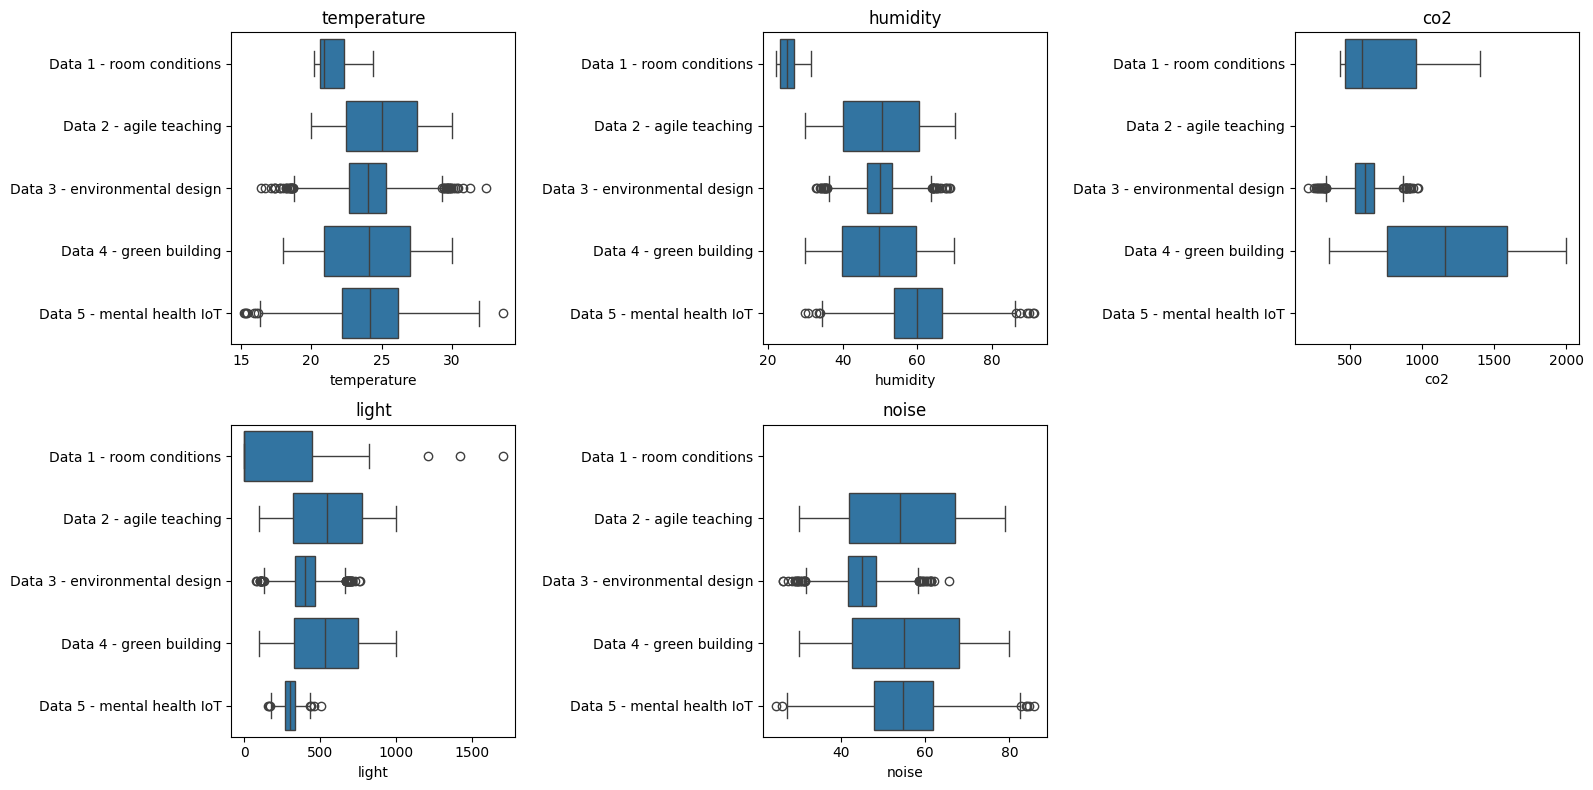

In [8]:
sample_first_five = (
    first_five
    .dropna(subset=["temperature", "humidity", "co2"], how="all")
    .groupby("dataset", group_keys=False)
    .apply(lambda frame: frame.sample(min(len(frame), 5000), random_state=42))
)

features_to_plot = ["temperature", "humidity", "co2", "light", "noise"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for index, feature in enumerate(features_to_plot):
    sns.boxplot(data=sample_first_five, x=feature, y="dataset", ax=axes[index])
    axes[index].set_title(feature)
    axes[index].set_ylabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Data 6: KETI resampled sensor data

The old markdown mentioned `combined_keti_sensor_data.csv`, but the current pipeline no longer depends on that file directly. The current script `scripts/resample_keti_data.py` reads the raw KETI room/sensor files directly and creates `data/interim/keti_1min_resampled.csv`.


In [9]:
keti = pd.read_csv(INTERIM_DIR / "keti_1min_resampled.csv", dtype={"room": str}, low_memory=False)

print(f"Rows: {len(keti):,}")
print(f"Columns: {len(keti.columns)}")
keti.head()

Rows: 604,891
Columns: 12


,room,timestamp,co2,humidity,light,temperature,pir,co2_observations,humidity_observations,light_observations,temperature_observations,pir_observations
0,413,2013-08-23 23:05:00,494.727273,45.3300,96.555556,23.927778,0.0,11,9,9,9,7
1,413,2013-08-23 23:06:00,496.666667,45.3275,96.833333,23.938333,0.0,12,12,12,12,6
2,413,2013-08-23 23:07:00,498.916667,45.3250,97.333333,23.942500,0.0,12,12,12,12,6
3,413,2013-08-23 23:08:00,504.166667,45.3125,97.083333,23.952500,0.0,12,12,12,12,6
4,413,2013-08-23 23:09:00,499.500000,45.3100,97.416667,23.955833,0.0,12,12,12,12,6


In [10]:
keti_missing = (
    keti[["co2", "humidity", "light", "temperature", "pir"]]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
)

keti_missing

,column,missing_percent
0,co2,13.01
1,humidity,9.31
2,light,9.31
3,temperature,9.31
4,pir,2.69


In [11]:
keti[["co2", "humidity", "light", "temperature", "pir"]].describe().round(2)

,co2,humidity,light,temperature,pir
count,526193.00,548600.00,548600.00,548602.00,588616.00
mean,421.63,56.75,82.28,23.16,0.06
std,91.09,4.30,309.00,1.07,0.23
min,250.00,42.12,0.00,20.18,0.00
25%,361.17,53.98,3.50,22.53,0.00
50%,414.75,57.01,4.33,23.10,0.00
75%,464.92,59.73,30.17,23.70,0.00
max,1669.50,71.88,2393.67,27.55,1.00


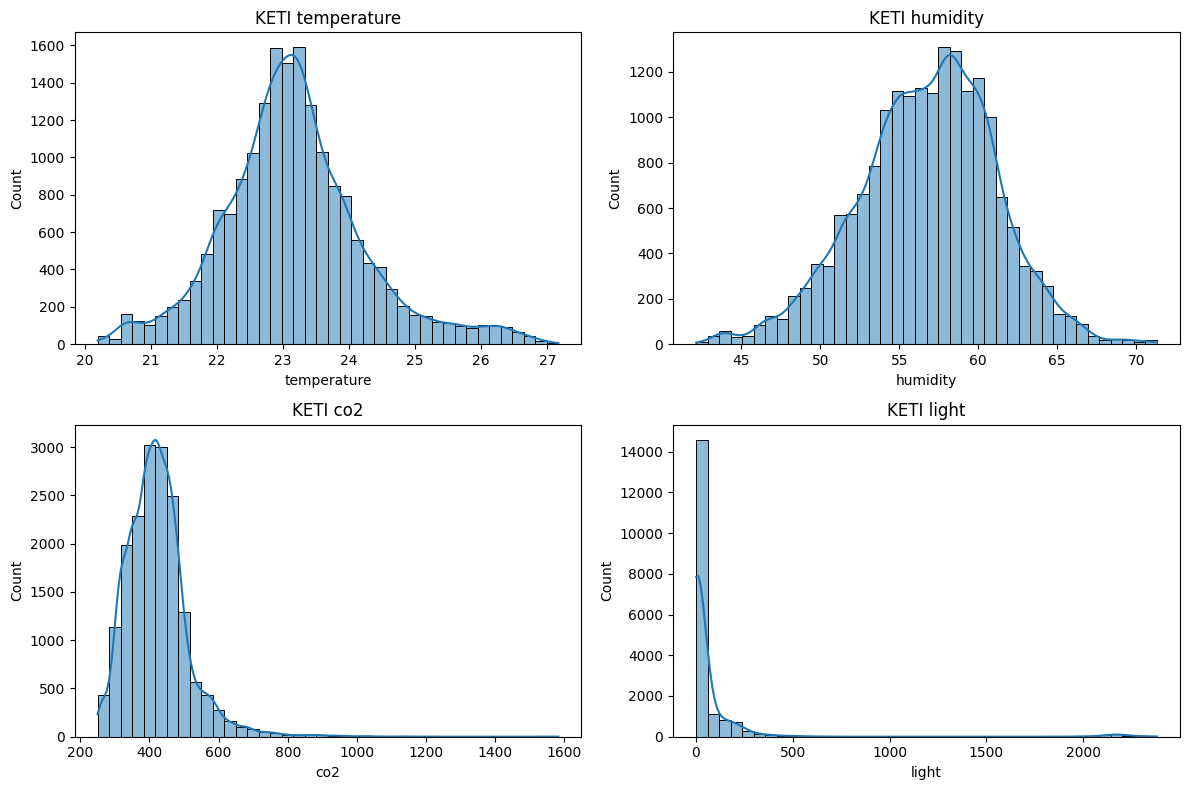

In [12]:
keti_sample = keti.sample(min(len(keti), 20000), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for index, feature in enumerate(["temperature", "humidity", "co2", "light"]):
    sns.histplot(keti_sample[feature].dropna(), bins=40, kde=True, ax=axes[index])
    axes[index].set_title(f"KETI {feature}")

plt.tight_layout()
plt.show()

## Data 7: HomeCoach 2023-2026

The HomeCoach data is split by year. Here we combine the yearly files only for analysis, so we can check whether the distributions and columns are consistent across time.


In [13]:
homecoach_frames = []

for path in sorted((RAW_DIR / "DATA_7").glob("HomeCoach_5min_*.csv")):
    year = path.stem.split("_")[-1]
    frame = pd.read_csv(path, low_memory=False)
    frame["year"] = year
    homecoach_frames.append(frame)

homecoach = pd.concat(homecoach_frames, ignore_index=True)

print(f"Rows: {len(homecoach):,}")
print(f"Columns: {len(homecoach.columns)}")
homecoach.head()

Rows: 311,692
Columns: 7


,timestamp,Temperature,Humidity,CO2,Noise,Pressure,year
0,2023-03-04 09:12:50,17.7,56,2305,67,1006.6,2023
1,2023-03-04 09:17:50,17.9,56,2250,73,1006.6,2023
2,2023-03-04 09:22:50,18.3,57,2286,77,1006.4,2023
3,2023-03-04 09:27:50,18.9,57,2266,58,1006.4,2023
4,2023-03-04 09:32:50,19.1,57,2238,54,1006.3,2023


In [14]:
homecoach_by_year = (
    homecoach
    .groupby("year")[["Temperature", "Humidity", "CO2", "Noise", "Pressure"]]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

homecoach_by_year

Temperature                    Humidity                    CO2           \
           count   mean   min   max    count   mean min max   count     mean   
year                                                                           
2023       77045  23.14  15.7  31.5    77045  50.88  29  69   77045   905.63   
2024      100325  22.03  15.6  31.6   100325  50.90  27  72  100325   841.48   
2025      100190  22.08  16.0  31.0   100190  52.29  31  72  100190   925.64   
2026       34132  20.10  15.8  25.2    34132  51.84  24  68   34132  1230.78   

                  Noise                Pressure                          
      min   max   count   mean min max    count     mean    min     max  
year                                                                     
2023  338  5000   77045  40.12  31  83    77045  1002.95  972.4  1030.4  
2024  333  4270  100325  40.50  31  80   100325  1004.31  978.0  1026.6  
2025  330  2757  100190  41.18  31  81   100190  1005.04  979.1  1025.3  
2026  329  3329   34132  39.87  31  81    34132  1001.49  973.9  1016.7

In [15]:
homecoach_missing = (
    homecoach
    .groupby("year")[["Temperature", "Humidity", "CO2", "Noise", "Pressure"]]
    .apply(lambda frame: frame.isna().mean().mul(100).round(2))
)

homecoach_missing

,Temperature,Humidity,CO2,Noise,Pressure
year,,,,,
2023,0.0,0.0,0.0,0.0,0.0
2024,0.0,0.0,0.0,0.0,0.0
2025,0.0,0.0,0.0,0.0,0.0
2026,0.0,0.0,0.0,0.0,0.0


C:\Users\mahru\AppData\Local\Temp\ipykernel_16432\4190098596.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(min(len(frame), 5000), random_state=42))


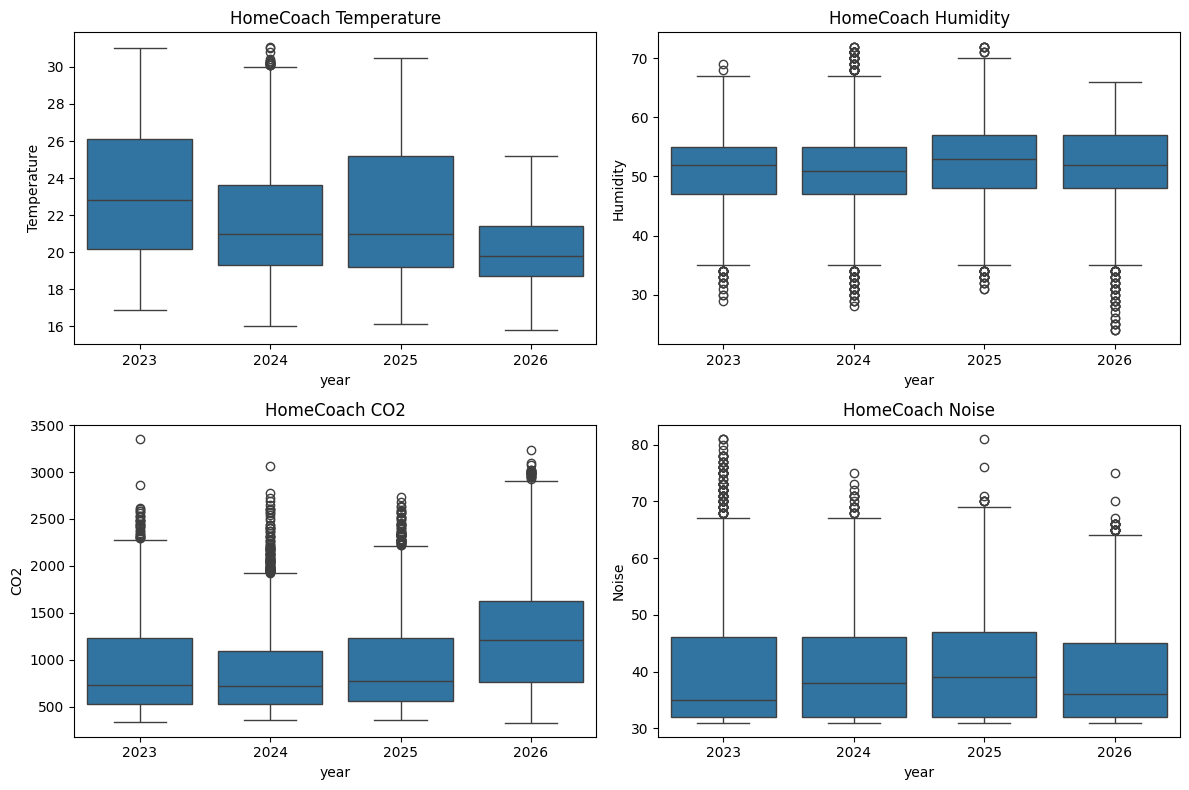

In [16]:
homecoach_sample = (
    homecoach
    .groupby("year", group_keys=False)
    .apply(lambda frame: frame.sample(min(len(frame), 5000), random_state=42))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for index, feature in enumerate(["Temperature", "Humidity", "CO2", "Noise"]):
    sns.boxplot(data=homecoach_sample, x="year", y=feature, ax=axes[index])
    axes[index].set_title(f"HomeCoach {feature}")

plt.tight_layout()
plt.show()

## Data 8: Room measurements and comfort perception

This dataset is useful because it has both measured room conditions and respondent comfort perception. The measurements can be matched with comfort responses by room and nearby timestamp.


In [17]:
comfort_dir = RAW_DIR / "DATA_8" / "smart-campus-comfort-data"

room_measurements = pd.read_csv(comfort_dir / "1_room_measurements.csv", low_memory=False)
comfort_perception = pd.read_csv(comfort_dir / "4_comfort_perception.csv", low_memory=False)

print(f"Room measurement rows: {len(room_measurements):,}")
print(f"Comfort perception rows: {len(comfort_perception):,}")

room_measurements.head()

Room measurement rows: 108,941
Comfort perception rows: 1,830


,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2
0,2025-09-15T00:00:03.000Z,70:ee:50:96:6b:50,Room 2.12,24.4,59.0,38.0,1018.7,413.0
1,2025-09-15T00:05:05.000Z,70:ee:50:96:6b:50,Room 2.12,24.5,59.0,39.0,1018.7,418.0
2,2025-09-15T00:10:08.000Z,70:ee:50:96:6b:50,Room 2.12,24.4,59.0,39.0,1018.7,421.0
3,2025-09-15T00:15:11.000Z,70:ee:50:96:6b:50,Room 2.12,24.4,59.0,38.0,1018.7,413.0
4,2025-09-15T00:20:14.000Z,70:ee:50:96:6b:50,Room 2.12,24.4,59.0,38.0,1018.8,413.0


In [18]:
comfort_perception.head()

,timestamp,respondentId,room,comfortValue,comfortLabel,temperatureValue,temperatureLabel,humidityValue,humidityLabel,airQualityValue,airQualityLabel,noiseValue,noiseLabel,degreesValue,degreesLabel,between,and
0,2025-09-17T13:37:11.000Z,13,Lab 4.2,4,Good,0,Optimal,0,Optimal,1,Acceptable,1,Slightly noisy,4,20≤t≤22°C,20.0,22.0
1,2025-09-17T13:37:50.000Z,31,Lab 4.2,5,Excellent,0,Optimal,0,Optimal,0,Optimal,1,Slightly noisy,5,23≤t≤25°C,23.0,25.0
2,2025-09-17T13:44:41.000Z,3,Lab 4.2,3,Acceptable,0,Optimal,1,Slightly humid,1,Acceptable,1,Slightly noisy,6,26≤t≤28°C,26.0,28.0
3,2025-09-17T13:46:32.000Z,7,Lab 4.2,4,Good,0,Optimal,0,Optimal,0,Optimal,0,Optimal,4,20≤t≤22°C,20.0,22.0
4,2025-09-17T14:09:50.000Z,26,Lab 4.2,4,Good,0,Optimal,0,Optimal,0,Optimal,1,Slightly noisy,5,23≤t≤25°C,23.0,25.0


In [19]:
room_measurement_summary = room_measurements[["temperature", "humidity", "noise", "CO2"]].describe().round(2)
room_measurement_summary

,temperature,humidity,noise,CO2
count,108917.00,108929.00,108900.00,108926.00
mean,21.67,48.20,49.33,540.13
std,2.69,8.55,9.58,157.25
min,10.20,24.00,32.00,333.00
25%,20.60,42.00,44.75,426.00
50%,21.70,48.00,50.00,489.00
75%,23.50,54.00,54.00,609.00
max,33.50,70.00,79.00,3181.00


In [20]:
comfort_counts = (
    comfort_perception["comfortValue"]
    .value_counts()
    .sort_index()
    .rename_axis("comfortValue")
    .reset_index(name="rows")
)

comfort_counts["percent"] = (comfort_counts["rows"] / comfort_counts["rows"].sum() * 100).round(2)
comfort_counts

,comfortValue,rows,percent
0,1,28,1.53
1,2,179,9.78
2,3,889,48.58
3,4,509,27.81
4,5,225,12.30


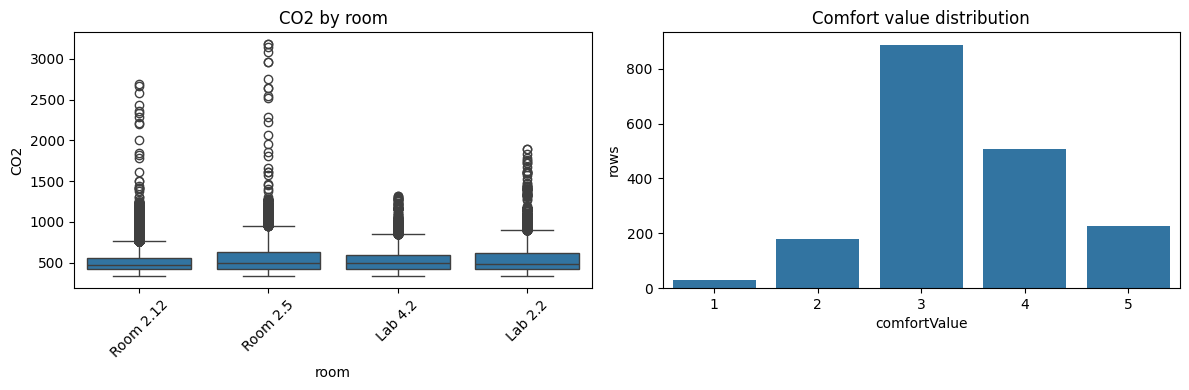

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=room_measurements, x="room", y="CO2", ax=axes[0])
axes[0].set_title("CO2 by room")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=comfort_counts, x="comfortValue", y="rows", ax=axes[1])
axes[1].set_title("Comfort value distribution")

plt.tight_layout()
plt.show()

## Final unified dataset

The final unified dataset is created by `scripts/build_unified_environment_dataset.py`. It standardises column names, adds source information, creates record IDs, and writes one common schema.


In [22]:
unified_path = PROCESSED_DIR / "unified_environment_focus_dataset.csv"
report_path = PROCESSED_DIR / "unified_environment_focus_dataset_report.csv"

unified = pd.read_csv(unified_path, low_memory=False)
source_report = pd.read_csv(report_path, low_memory=False)

print(f"Rows: {len(unified):,}")
print(f"Columns: {len(unified.columns)}")
unified.head()

Rows: 866,348
Columns: 11


,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23T16:06:00Z,keti_1min_resampled__510__s00001,510,keti_1min_resampled:row_00192329,keti_1min_resampled,NaN,NaN,NaN,NaN,316.000000,NaN
1,2013-08-23T16:24:00Z,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011995,keti_1min_resampled,NaN,NaN,NaN,NaN,476.555556,NaN
2,2013-08-23T16:25:00Z,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011996,keti_1min_resampled,NaN,NaN,NaN,NaN,480.333333,NaN
3,2013-08-23T16:26:00Z,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011997,keti_1min_resampled,NaN,NaN,NaN,NaN,485.166667,NaN
4,2013-08-23T16:27:00Z,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011998,keti_1min_resampled,NaN,NaN,NaN,NaN,481.083333,NaN


In [23]:
source_report

,source,input_path,raw_rows,output_rows,dropped_empty_rows,first_timestamp,last_timestamp,unique_locations,unique_sessions,labeled_rows,temperature_nonnull,humidity_nonnull,light_nonnull,noise_nonnull,co2_nonnull,status
0,keti_1min_resampled,data\interim\keti_1min_resampled.csv,604891,550161,54730,2013-08-23 16:06:00+00:00,2013-09-01 06:58:00+00:00,51,134,0,548602,548600,548600,0,526193,ok
1,room_conditions,data\raw\room_conditions.csv,2665,2665,0,2015-02-02 14:19:00+00:00,2015-02-04 10:43:00+00:00,1,1,0,2665,2665,2665,0,2665,ok
2,room_measurements_with_comfort,data\processed\1_room_measurements_with_comfor...,1830,1830,0,2025-09-17 13:37:11+00:00,2025-12-19 14:01:19+00:00,4,71,1830,1830,1830,0,1830,1830,ok
3,homecoach_5min_2023,data\raw\HomeCoach_5min_2023.csv,77045,77045,0,2023-03-04 09:12:50+00:00,2023-12-31 23:59:31+00:00,1,10,0,77045,77045,0,77045,77045,ok
4,homecoach_5min_2024,data\raw\HomeCoach_5min_2024.csv,100325,100325,0,2024-01-01 00:02:30+00:00,2024-12-31 23:54:31+00:00,1,5,0,100325,100325,0,100325,100325,ok
5,homecoach_5min_2025,data\raw\HomeCoach_5min_2025.csv,100190,100190,0,2025-01-01 00:02:30+00:00,2025-12-31 23:59:31+00:00,1,1,0,100190,100190,0,100190,100190,ok
6,homecoach_5min_2026,data\raw\HomeCoach_5min_2026.csv,34132,34132,0,2026-01-01 00:02:30+00:00,2026-05-06 15:47:49+00:00,1,5,0,34132,34132,0,34132,34132,ok


In [24]:
source_counts = (
    unified["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="rows")
)

source_counts["percent"] = (source_counts["rows"] / len(unified) * 100).round(2)
source_counts

,source,rows,percent
0,keti_1min_resampled,550161,63.50
1,homecoach_5min_2024,100325,11.58
2,homecoach_5min_2025,100190,11.56
3,homecoach_5min_2023,77045,8.89
4,homecoach_5min_2026,34132,3.94
5,room_conditions,2665,0.31
6,room_measurements_with_comfort,1830,0.21


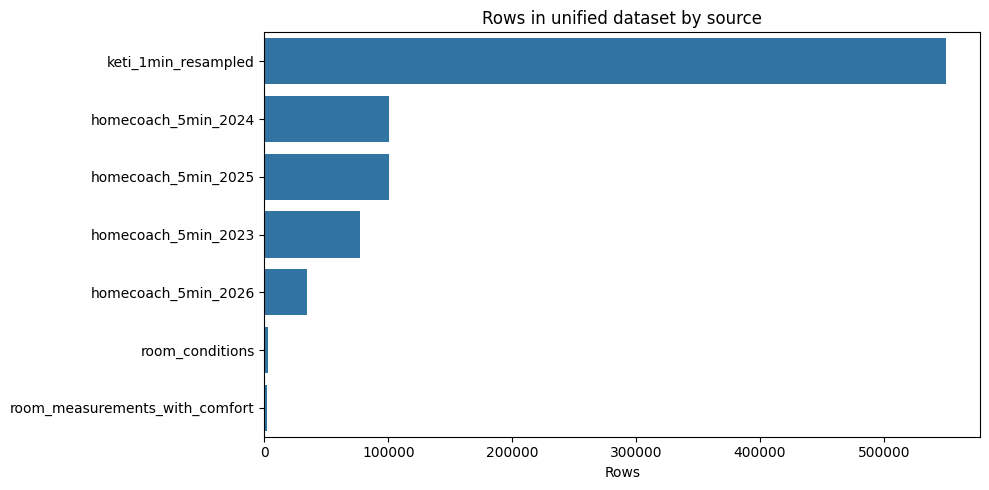

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=source_counts, y="source", x="rows")
plt.title("Rows in unified dataset by source")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [26]:
unified_missing = (
    unified
    .isna()
    .sum()
    .rename("missing_rows")
    .reset_index()
    .rename(columns={"index": "column"})
)

unified_missing["missing_percent"] = (unified_missing["missing_rows"] / len(unified) * 100).round(2)
unified_missing.sort_values("missing_rows", ascending=False)

,column,missing_rows,missing_percent
10,focus_score,864518,99.79
8,noise,552826,63.81
6,light,315083,36.37
9,co2,23968,2.77
5,humidity,1561,0.18
7,temperature,1559,0.18
0,timestamp,0,0.00
2,location_id,0,0.00
1,session_id,0,0.00
3,record_id,0,0.00


In [27]:
unified[["temperature", "humidity", "light", "noise", "co2", "focus_score"]].describe().round(2)

,temperature,humidity,light,noise,co2,focus_score
count,864789.00,864787.00,551265.00,313522.00,842380.00,1830.00
mean,22.78,54.72,82.82,40.67,610.24,3.40
std,2.29,6.00,308.84,9.66,379.99,0.88
min,15.60,22.10,0.00,31.00,250.00,1.00
25%,21.70,51.27,3.50,32.00,394.25,3.00
50%,22.91,55.45,4.25,37.00,463.33,3.00
75%,23.80,58.88,30.42,46.00,638.17,4.00
max,31.60,72.00,2393.67,83.00,5000.00,5.00


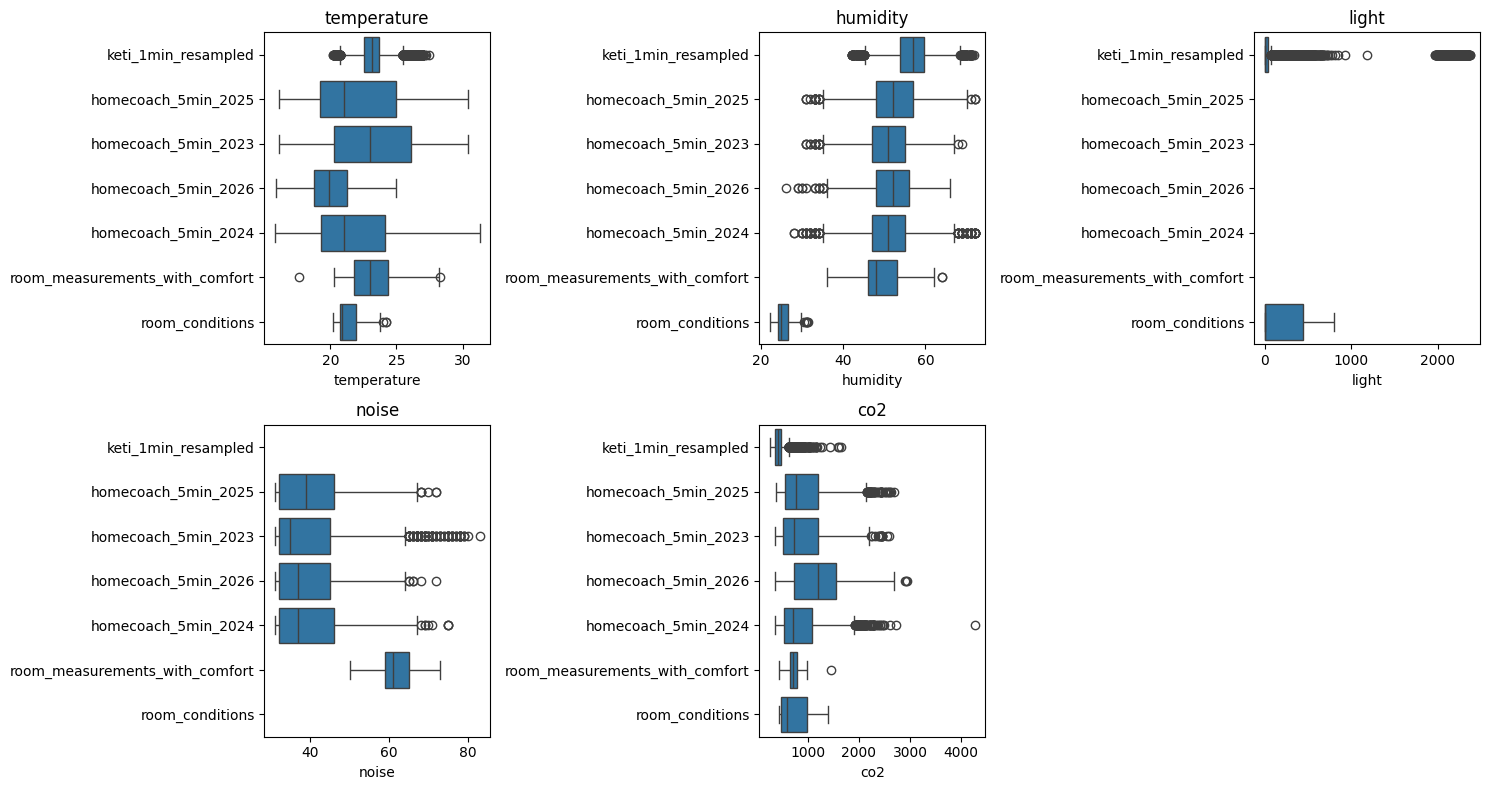

In [28]:
unified_sample = unified.sample(min(len(unified), 30000), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for index, feature in enumerate(["temperature", "humidity", "light", "noise", "co2"]):
    sns.boxplot(data=unified_sample, x=feature, y="source", ax=axes[index])
    axes[index].set_title(feature)
    axes[index].set_ylabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Target labels

Only a small part of the unified dataset has direct target labels. The later pipeline fills missing `focus_score` values using respondent comfort data. That step is handled outside this notebook by `scripts/fill_missing_targets.py`.


In [29]:
labeled_rows = unified[unified["focus_score"].notna()].copy()

print(f"Rows with focus_score: {len(labeled_rows):,}")
print(f"Rows without focus_score: {unified['focus_score'].isna().sum():,}")

if len(labeled_rows) > 0:
    target_counts = (
        labeled_rows["focus_score"]
        .value_counts()
        .sort_index()
        .rename_axis("focus_score")
        .reset_index(name="rows")
    )
    target_counts["percent"] = (target_counts["rows"] / target_counts["rows"].sum() * 100).round(2)
    display(target_counts)

Rows with focus_score: 1,830
Rows without focus_score: 864,518


,focus_score,rows,percent
0,1.0,28,1.53
1,2.0,179,9.78
2,3.0,889,48.58
3,4.0,509,27.81
4,5.0,225,12.30


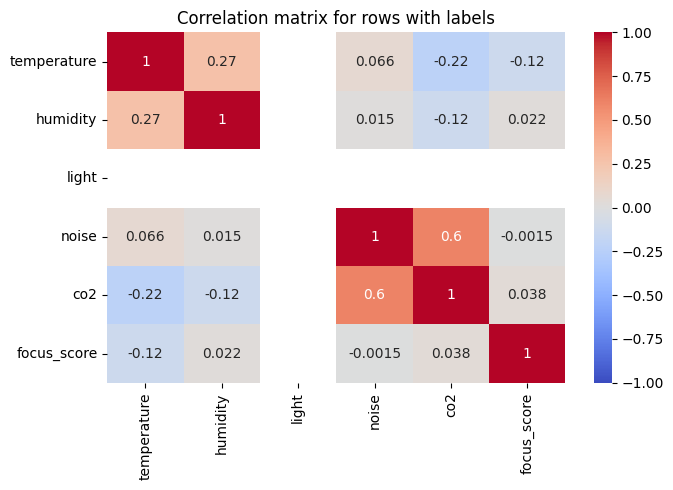

In [30]:
if len(labeled_rows) > 0:
    corr_cols = ["temperature", "humidity", "light", "noise", "co2", "focus_score"]
    corr = labeled_rows[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Correlation matrix for rows with labels")
    plt.tight_layout()
    plt.show()

## Current processed outputs

The later preprocessing stages write filled target labels and 30-minute linearized session windows. These are the files used for model training.


In [31]:
processed_outputs = {
    "unified dataset": PROCESSED_DIR / "unified_environment_focus_dataset.csv",
    "respondent-filled focus score dataset": PROCESSED_DIR / "unified_environment_respondent_focus_score_filled.csv",
    "linearized 30 minute windows": PROCESSED_DIR / "linearized_session_windows_30min.csv",
    "linearized session report": PROCESSED_DIR / "linearized_session_windows_30min_report.csv",
}

processed_summary = []

for name, path in processed_outputs.items():
    if not path.exists():
        processed_summary.append({"file": name, "exists": False})
        continue

    preview = pd.read_csv(path, nrows=5, low_memory=False)
    rows = sum(1 for _ in open(path, encoding="utf-8", errors="ignore")) - 1
    processed_summary.append({
        "file": name,
        "exists": True,
        "rows": rows,
        "columns": len(preview.columns),
        "path": str(path),
    })

pd.DataFrame(processed_summary)

,file,exists,rows,columns,path
0,unified dataset,True,866348,11,..\..\data\processed\unified_environment_focus...
1,respondent-filled focus score dataset,True,840826,11,..\..\data\processed\unified_environment_respo...
2,linearized 30 minute windows,True,840826,36,..\..\data\processed\linearized_session_window...
3,linearized session report,True,281,7,..\..\data\processed\linearized_session_window...


## Final notes

The combined analysis shows that the datasets do not all have the same sensors or target labels. Because of that, the project uses scripts to standardise the selected sources into one schema before target filling and session linearization.

The main files for the current pipeline are:

1. `scripts/resample_keti_data.py`
2. `scripts/build_unified_environment_dataset.py`
3. `scripts/fill_missing_targets.py`
4. `scripts/linearize_session_windows.py`

This notebook is the readable analysis layer. The scripts are the reproducible pipeline layer.
